/opt/anaconda3/lib/python3.12/site-packages/qutip/solver/options.py:16: FutureWarning: Dedicated options class are no longer needed, options should be passed as dict to solvers.
  warnings.warn(


N= 2, τ=0.4808, Eb=1.190632, Ergotropy=1.029524, erg/Eb=0.864686352329 Variance=8.2259464545e-01
N= 3, τ=0.5060, Eb=1.908804, Ergotropy=1.739145, erg/Eb=0.911117513418 Variance=1.2453818951e+00
N= 4, τ=0.5206, Eb=2.645386, Ergotropy=2.470733, erg/Eb=0.933978321874 Variance=1.6549355891e+00
N= 5, τ=0.5303, Eb=3.392296, Ergotropy=3.214302, erg/Eb=0.947530124049 Variance=2.0548315175e+00
N= 6, τ=0.5371, Eb=4.144388, Ergotropy=3.964055, erg/Eb=0.956487470104 Variance=2.4478686379e+00
N= 7, τ=0.5422, Eb=4.900310, Ergotropy=4.718218, erg/Eb=0.962840746023 Variance=2.8358777741e+00
N= 8, τ=0.5461, Eb=5.658156, Ergotropy=5.474723, erg/Eb=0.967580687632 Variance=3.2203554382e+00
N= 9, τ=0.5493, Eb=6.418688, Ergotropy=6.234145, erg/Eb=0.971249177173 Variance=3.6016964324e+00
N=10, τ=0.5518, Eb=7.179101, Ergotropy=6.993701, erg/Eb=0.974175030460 Variance=3.9814169601e+00
N=11, τ=0.5540, Eb=7.942078, Ergotropy=7.755913, erg/Eb=0.976559659265 Variance=4.3587360219e+00
N=12, τ=0.5558, Eb=8.704925, E

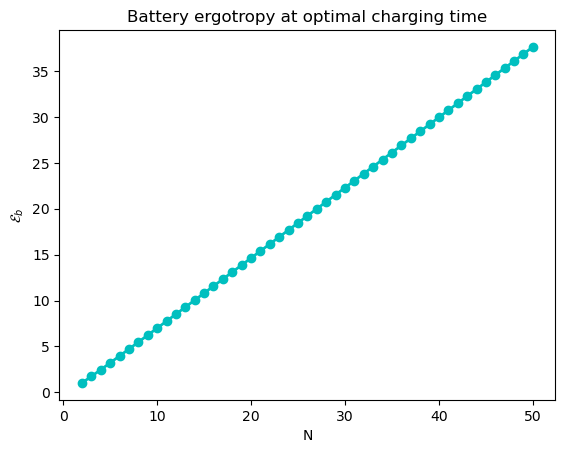

In [1]:
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt

############
# parameters
############

N_arr = np.arange(2, 51, 1)
nmax = 80
ω = 1.0
ω0 = 1.0
g = 1.0
tlist = np.arange(0.01, (2*np.pi), 0.0001)

######################
# collective operators
######################

def collective_ops(N):
    Jp = qt.jmat(N/2, '+')
    Jm = Jp.dag()
    Jz = qt.jmat(N/2, 'z')
    HB = Jz + (N/2)*qt.qeye(N+1)
    return Jp, Jm, HB

#############################
# Dicke Hamiltonian
#############################

def dicke_fun(N, nmax, ω, ω0, g):
    
    a = qt.destroy(nmax)
    Ic = qt.qeye(nmax)
    Jp, Jm, HB = collective_ops(N)
    IB = qt.qeye(N + 1)
    
    H = ω  * qt.tensor(a.dag() * a, IB) + ω0 * qt.tensor(Ic, HB) + g * (1.0 / np.sqrt(N) * qt.tensor(a + a.dag(), Jp + Jm))
    
    return H, HB

################
# Initial state
################

def initial_state(N, nmax, state):
    if state=="coherent":
        psiA = qt.coherent(nmax, np.sqrt(N))
    elif state=="fock":
        psiA = qt.basis(nmax, N)
    psiB = qt.basis(N+1, N)  
    return qt.tensor(psiA, psiB)

#########################################
# optimal charging time τ (maximum power)
#########################################

τ_list = []

for N in N_arr:
    H, HB = dicke_fun(N, nmax, ω, ω0, g)
    HB_full = qt.tensor(qt.qeye(nmax), HB)
    psi0 = initial_state(N, nmax, "coherent")

    opts = qt.Options(atol=1e-16, rtol=1e-14)         ## ODE solver options
    res = qt.sesolve(H, psi0, tlist, e_ops=HB_full, options=opts)
    EB = np.array(res.expect[0])
    power = EB / tlist

    τ_list.append(tlist[np.argmax(power)])

###########################################
# Calculation of ergotropy and fluctuations
###########################################

E_ratio, E_ergo, E_var, F_ratio, FE_ratio = [], [], [], [], []

for i, N in enumerate(N_arr):

    τ = τ_list[i]
    
    H, HB = dicke_fun(N, nmax, ω, ω0, g)
    
    psi0 = initial_state(N, nmax, "coherent")

    res = qt.sesolve(H, psi0, [0, τ], options=opts)
    
    rho_b = res.states[-1].ptrace(1)

    E_B = qt.expect(HB, rho_b)
    
    r_vals, r_vecs = rho_b.eigenstates()

    # Clip numerical noise to prevent negative probabilities
    r_vals = np.maximum(r_vals, 0) 
    # Renormalize 
    r_vals = r_vals / np.sum(r_vals)
        
    idx = np.argsort(r_vals)[::-1]
    r_vals = r_vals[idx]
    r_vecs = [r_vecs[i] for i in idx]

    # assign degenerate energies 
    e_vals = np.array([0] + [ω0]*N)
    
    # e_vals = np.arange(N + 1) * ω0
    
    E_B = qt.expect(HB, rho_b)
    
    E_erg = E_B - sum(r_vals[j]*e_vals[j] for j in range(len(r_vals)))

    W_2 = (qt.expect(HB**2, rho_b) + sum(r_vals[j]*(e_vals[j])**2 for j in range(len(r_vals)))) - 2 * sum(e_vals[i]*r_vals[i]*qt.expect(HB, r_vecs[i]) for i in range(len(r_vals)))
    
    ΔE2 = W_2 - (E_erg)**2
    
    ΔE = np.sqrt(ΔE2)

    Ratio = E_erg / E_B
    
    E_ergo.append(E_erg)

    E_var.append(ΔE2)
    
    E_ratio.append(Ratio)
    
    F_ratio.append(ΔE / E_erg)

    FE_ratio.append(ΔE / E_B)


    print(f"N={N:2d}, τ={τ:.4f}, Eb={E_B:.6f}, Ergotropy={E_erg:.6f}, erg/Eb={Ratio:.12f} Variance={ΔE2:.10e}")


###############################################################
# Plot of battery ergotropy at optimal charging for different N 
###############################################################

plt.plot(N_arr, E_ergo, 'o-', color='c', linewidth=2)
plt.xlabel("N")
plt.ylabel(r"$\mathcal{E}_b$")
plt.title("Battery ergotropy at optimal charging time")
#plt.savefig("OP1")
plt.show()

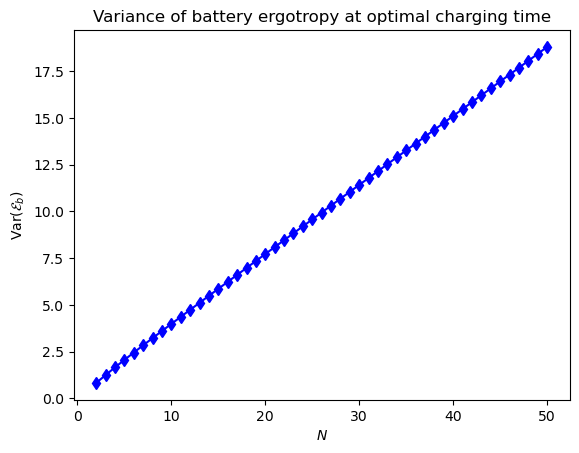

In [2]:
###########################################################################
# Plot of variance of battery ergotropy at optimal charging for different N 
###########################################################################

plt.figure()
plt.plot(N_arr, E_var, 'd-', color='b')
plt.xlabel(r"$N$")
plt.ylabel(r"$\mathrm{Var}(\mathcal{E}_b)$")
plt.title("Variance of battery ergotropy at optimal charging time")
#plt.savefig("OP2")
plt.show()

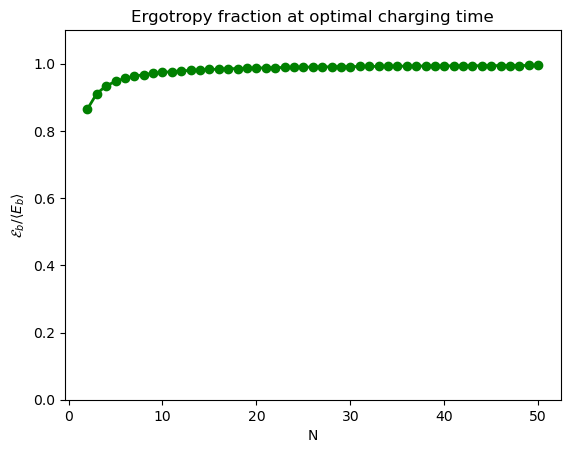

In [3]:
#############################################################
# Plot ergotropy fraction as a function of g for different N 
############################################################
    
plt.plot(N_arr, E_ratio, 'o-', color='g', linewidth=2)
plt.xlabel("N")
plt.ylabel(r"$\mathcal{E}_b / \langle E_b \rangle$")
plt.ylim(0,1.1)
plt.title("Ergotropy fraction at optimal charging time")
#plt.savefig("OP3")
plt.show()

N= 2, τ=0.4808, Relative Fluctuation =0.880960936870, Relative Fluctuation with Eb =0.761754899046
N= 3, τ=0.5060, Relative Fluctuation =0.641675700248, Relative Fluctuation with Eb =0.584641968431
N= 4, τ=0.5206, Relative Fluctuation =0.520672587276, Relative Fluctuation with Eb =0.486296909310
N= 5, τ=0.5303, Relative Fluctuation =0.445965614811, Relative Fluctuation with Eb =0.422565854323
N= 6, τ=0.5371, Relative Fluctuation =0.394688433084, Relative Fluctuation with Eb =0.377514540840
N= 7, τ=0.5422, Relative Fluctuation =0.356915807194, Relative Fluctuation with Eb =0.343653082066
N= 8, τ=0.5461, Relative Fluctuation =0.327785534475, Relative Fluctuation with Eb =0.317158952843
N= 9, τ=0.5493, Relative Fluctuation =0.304422430073, Relative Fluctuation with Eb =0.295670034721
N=10, τ=0.5518, Relative Fluctuation =0.285306588571, Relative Fluctuation with Eb =0.277938554611
N=11, τ=0.5540, Relative Fluctuation =0.269182836339, Relative Fluctuation with Eb =0.262873098935
N=12, τ=0.

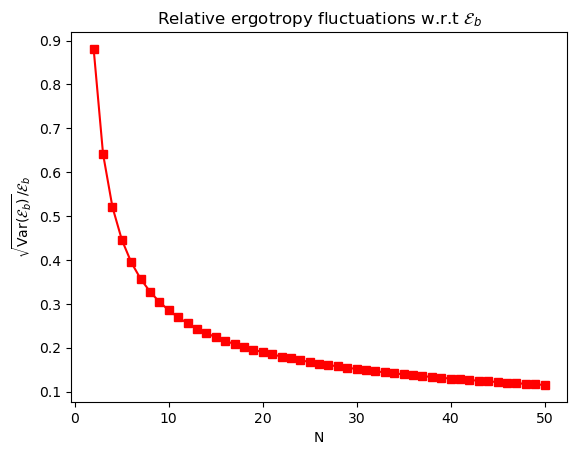

In [4]:
for idx, N in enumerate(N_arr):
    print(f"N={N:2d}, τ={τ_list[idx]:.4f}, Relative Fluctuation ={F_ratio[idx]:.12f}, Relative Fluctuation with Eb ={FE_ratio[idx]:.12f}")


######################################################
# Plot fluctuations as a function of g for different N 
######################################################

plt.plot(N_arr, F_ratio, 's-', color='r')
plt.xlabel("N")
plt.ylabel(r"$\sqrt{\mathrm{Var}(\mathcal{E}_b)}/\mathcal{E}_b$")
plt.title(r"Relative ergotropy fluctuations w.r.t $\mathcal{E}_b$")
#plt.savefig("OP4")
plt.show()

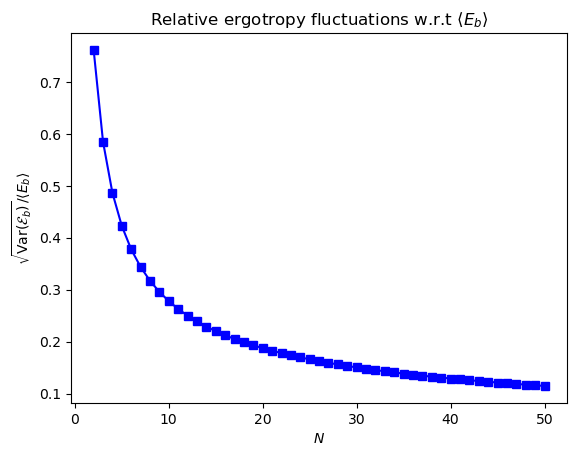

In [5]:
##########################################################################
# Plot fluctuations w.r.t battery energy as function of g for different N 
##########################################################################

plt.figure()
plt.plot(N_arr, FE_ratio, 's-', color='b')
plt.xlabel(r"$N$")
plt.ylabel(r"$\sqrt{\mathrm{Var}(\mathcal{E}_b)}/ \langle E_b \rangle$")
plt.title(r"Relative ergotropy fluctuations w.r.t $\langle E_b \rangle$")
plt.savefig("OP5")
plt.show()

Best fit parameters: A = 0.000329, B = 0.276560, Optimal value for alpha: 1.035780


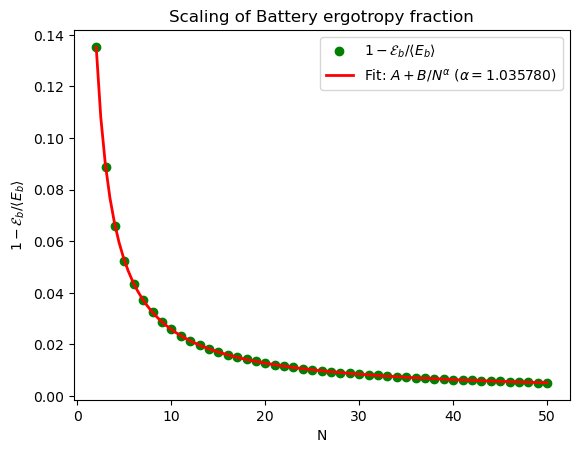

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# The fitting function
def asymptotic_fit(N, alpha, A, B):
    return (A + B / (N**alpha))


y_data = 1 - np.array(E_ratio) 

# The curve fit

popt, pcov = curve_fit(asymptotic_fit, N_arr, y_data)
alpha_opt, A_opt, B_opt = popt

print(f"Best fit parameters: A = {A_opt:.6f}, B = {B_opt:.6f}, Optimal value for alpha: {alpha_opt:.6f}")

# A smooth curve for the fit using the optimal parameters

N_smooth = np.linspace(min(N_arr), max(N_arr), 100)
y_fit = asymptotic_fit(N_smooth, alpha_opt, A_opt, B_opt)

# Plot the original data and the fitted curve

plt.plot(N_arr, y_data, 'o', color='g', markersize=6, label=r"$1 - \mathcal{E}_b / \langle E_b \rangle$")
plt.plot(N_smooth, y_fit, '-', color='r', linewidth=2, label=rf'Fit: $A + B/N^{{\alpha}}$ ($\alpha={alpha_opt:.6f}$)')

plt.xlabel("N")
plt.ylabel(r"$1 - \mathcal{E}_b / \langle E_b \rangle$")
plt.title("Scaling of Battery ergotropy fraction")
plt.legend()
#plt.savefig("OP6")
plt.show()

Best fit parameters: A = 0.054088, B = 1.414433, Optimal value for alpha: 0.788989


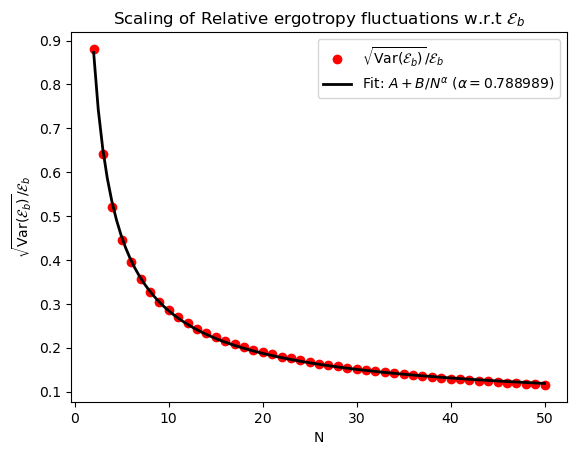

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Fitting function
def asymptotic_fit(N, alpha, A, B):
    return (A + B / (N**alpha))

y_data = np.array(F_ratio) 

# The curve fit
popt, pcov = curve_fit(asymptotic_fit, N_arr, y_data)
alpha_opt, A_opt, B_opt = popt

print(f"Best fit parameters: A = {A_opt:.6f}, B = {B_opt:.6f}, Optimal value for alpha: {alpha_opt:.6f}")

# A smooth curve for the fit using the optimal alpha

N_smooth = np.linspace(min(N_arr), max(N_arr), 100)
y_fit = asymptotic_fit(N_smooth, alpha_opt, A_opt, B_opt)

# Plot the original data and the fitted curve

plt.plot(N_arr, y_data, 'o', color='r', markersize=6, label=r"$\sqrt{\mathrm{Var}(\mathcal{E}_b)}/\mathcal{E}_b$")
plt.plot(N_smooth, y_fit, '-', color='k', linewidth=2, label=rf'Fit: $A + B/N^{{\alpha}}$ ($\alpha={alpha_opt:.6f}$)')

plt.xlabel("N")
plt.ylabel(r"$\sqrt{\mathrm{Var}(\mathcal{E}_b)}/\mathcal{E}_b$")
plt.title(r"Scaling of Relative ergotropy fluctuations w.r.t $\mathcal{E}_b$")
plt.legend()
#plt.savefig("OP7")
plt.show()